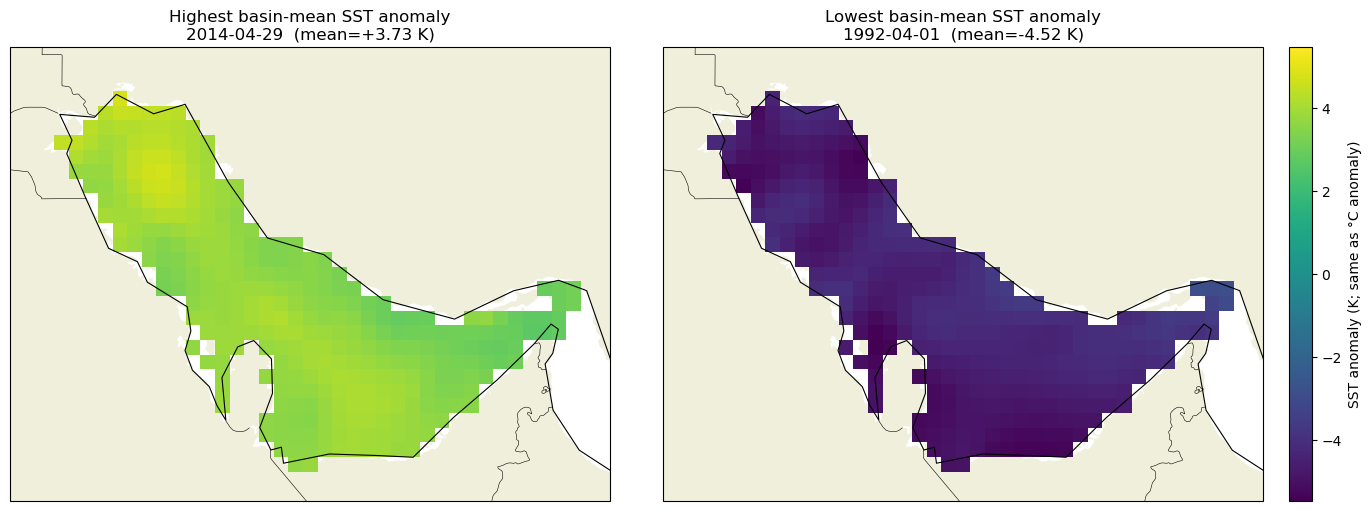

In [3]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- paths ----
NETID = "k16v981"
OUT_DIR = f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes/data/sst/basin_anoms"
FN = os.path.join(OUT_DIR, "era5_sst_anom_arabian_gulf_1950_2025.nc")

ds = xr.open_dataset(FN)
da = ds["sst_anom"]

# ---- coordinate names ----
lat_name = "latitude" if "latitude" in da.coords else "lat"
lon_name = "longitude" if "longitude" in da.coords else "lon"

# If lon is 0..360, shift to -180..180 for nicer plotting
lon = da[lon_name]
if float(lon.max()) > 180:
    lon_new = ((lon + 180) % 360) - 180
    da = da.assign_coords({lon_name: lon_new}).sortby(lon_name)

# ---- basin-mean time series (area-weighted) to find max/min months ----
# weights ~ cos(lat); masked ocean points are NaN already, so weighted mean respects mask
# ---- basin-mean time series (area-weighted) to find max/min months ----
w = np.cos(np.deg2rad(da[lat_name]))
w = w / w.mean()

ts = da.weighted(w).mean(dim=(lat_name, lon_name), skipna=True)

# Use integer indices (robust to datetime/cftime quirks)
i_max = int(ts.argmax("time").values)
i_min = int(ts.argmin("time").values)

t_max = da["time"].isel(time=i_max).values
t_min = da["time"].isel(time=i_min).values

da_max = da.isel(time=i_max)
da_min = da.isel(time=i_min)

mean_max = float(ts.isel(time=i_max).values)
mean_min = float(ts.isel(time=i_min).values)


# shared color limits (symmetric)
v = float(np.nanmax(np.abs([da_max.values, da_min.values])))
v = max(v, 0.1)  # avoid 0-range if something weird happens

# ---- plot ----
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={"projection": proj}, constrained_layout=True)

for ax, field, title in [
    (axes[0], da_max, f"Highest basin-mean SST anomaly\n{str(t_max)[:10]}  (mean={mean_max:+.2f} K)"),
    (axes[1], da_min, f"Lowest basin-mean SST anomaly\n{str(t_min)[:10]}  (mean={mean_min:+.2f} K)"),
]:
    im = ax.pcolormesh(
        field[lon_name],
        field[lat_name],
        field,
        transform=ccrs.PlateCarree(),
        vmin=-v, vmax=v,
        shading="auto",
    )
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, linewidth=0.2)
    ax.set_title(title)

# one shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("SST anomaly (K; same as °C anomaly)")

plt.show()


In [4]:
print("da.time dtype:", da["time"].dtype)
print("example da.time:", da["time"].values[:3])
print("example ts.time:", ts["time"].values[:3])

da.time dtype: datetime64[ns]
example da.time: ['1950-01-01T00:00:00.000000000' '1950-01-01T06:00:00.000000000'
 '1950-01-01T12:00:00.000000000']
example ts.time: ['1950-01-01T00:00:00.000000000' '1950-01-01T06:00:00.000000000'
 '1950-01-01T12:00:00.000000000']
